In [1]:
import torch
import math
import random
import utilities

from tqdm import tqdm
import interconnect_calculator as inter_cal
import temperature_calculator as temp_cal
import chip_temp_pred_models as ctpm

# 自动检测设备
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# 辅助函数：重叠检测
# ==========================================
def is_2_chip_overlapping_cuda(chip1, chip2, min_edge_dist: float = 0.2):
    """
    检测两个芯粒是否重叠
    """
    x1, y1, w1, h1 = chip1[0], chip1[1], chip1[2], chip1[3]
    x2, y2, w2, h2 = chip2[0], chip2[1], chip2[2], chip2[3]

    # 判断不重叠的条件 (逆向思维)
    no_overlap = (
        (x1 + w1 + min_edge_dist <= x2) or
        (x2 + w2 + min_edge_dist <= x1) or
        (y1 + h1 + min_edge_dist <= y2) or
        (y2 + h2 + min_edge_dist <= y1)
    )
    return not no_overlap

def check_overlap_within_layout_cuda(layout, min_edge_dist: float = 0.2):
    """
    检测整个布局中是否存在任何重叠
    """
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE)
    
    n = len(layout)
    # 获取上三角索引 (排除自身对比和重复对比)
    i_indices, j_indices = torch.triu_indices(n, n, offset=1)
    
    # 向量化或列表推导式检查
    # 注意：为了性能，这里保留了你原来列表推导式的逻辑结构，但为了更易读封装在函数内
    overlaps = [
        bool(is_2_chip_overlapping_cuda(layout[i], layout[j], min_edge_dist=min_edge_dist))
        for i, j in zip(i_indices, j_indices)
    ]

    return any(overlaps)

# ==========================================
# 核心函数：计算能量值 (Cost Function)
# ==========================================

def get_chiplet_dict_cuda(chip_length, chip_width, Convection_Film_Coefficient, Internal_Heat_Generation_Magnitude):
    """
    根据芯粒基础参数构建字典，并调用热模型预测 A/k 系数。
    这样 SA 与 stage2_1_cuda03 的热参数口径保持一致。
    """
    chip = {}
    chip['len'] = chip_length
    chip['wid'] = chip_width
    chip['CFC'] = Convection_Film_Coefficient
    chip['IHGM'] = Internal_Heat_Generation_Magnitude

    chip['A'], chip['k'] = ctpm.get_out_chip_decay_curve_coef(
        chip_len=chip['len'],
        chip_wid=chip['wid'],
        Convection_Film_Coefficient=chip['CFC'],
        Internal_Heat_Generation_Magnitude=chip['IHGM']
    )
    return chip


def is_overlapping_in_init_grid_cuda(x_c, y_c, len_c, wid_c, index_c, layout, min_edge_dist=0.2):
    curr_chip = torch.tensor([x_c, y_c, len_c, wid_c, float(index_c)], device=DEVICE, dtype=torch.float32)

    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE, dtype=torch.float32)

    if layout.numel() == 0:
        return False

    for chip in layout:
        if is_2_chip_overlapping_cuda(curr_chip, chip, min_edge_dist=min_edge_dist):
            return True
    return False


def generate_a_layout_cuda(grid_length, grid_width, chiplets, min_edge_distance=2.0, margin_width=1.0):
    layout = torch.empty((0, 5), device=DEVICE, dtype=torch.float32)

    for index, chip in chiplets.items():
        placed = False
        attempts = 0

        while (not placed) and attempts < 2000:
            x = random.uniform(0, max(0.0, grid_length - chip['len']))
            y = random.uniform(0, max(0.0, grid_width - chip['wid']))

            if not is_overlapping_in_init_grid_cuda(
                x, y, chip['len'], chip['wid'], index, layout, min_edge_dist=min_edge_distance
            ):
                chip_tensor = torch.tensor([x, y, chip['len'], chip['wid'], float(index)], device=DEVICE, dtype=torch.float32)
                layout = torch.cat((layout, chip_tensor.unsqueeze(0)), dim=0)
                placed = True

            attempts += 1

        if not placed:
            raise RuntimeError(f'Cannot place chiplet {index} without overlap after many attempts.')

    x_min = torch.min(layout[:, 0]).item()
    y_min = torch.min(layout[:, 1]).item()

    layout[:, 0] -= (x_min - margin_width)
    layout[:, 1] -= (y_min - margin_width)

    return layout


def calculate_energy(layout, connectivity, chiplets, weights=None, min_edge_distance: float = 0.2):
    """
    计算 Chiplet 布局的能量值 (Cost/Fitness)。
    能量值越低，布局越优。

    Args:
        layout (torch.Tensor): 布局张量 [N, 5] (x, y, len, wid, index)。
        connectivity (list): 连通性列表。
        chiplets (dict): 芯粒属性字典。
        weights (dict, optional): 权重字典，用于调节各指标的重要性。
                                  默认值基于 GA 代码逻辑设定。

    Returns:
        float: 总能量值 (Total Cost)。
    """
    # 0. 预处理与默认权重配置
    if weights is None:
        weights = {
            'interconnect': 1.0,      # 连线长度权重
            'temp_uniformity': 1.0,   # 温度均匀度权重
            'max_temp': 0.1,          # 最大温度权重（与 stage2_1_cuda03.ipynb 保持一致）
            'overlap': 10000.0,       # 重叠惩罚权重 (硬约束)
            'spread': 0.2             # 分散惩罚权重
        }
    
    # 确保 layout 在正确的设备上
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE, dtype=torch.float32)
    else:
        layout = layout.to(DEVICE)

    # 1. 计算连线长度 (Interconnect Length)
    # 调用现有的 interconnect_calculator
    inter_connect_length = inter_cal.get_total_interconnect_length_cuda(
        layout=layout,
        connectivity_pairs=connectivity
    )

    # 2. 计算热分布 (Thermal)
    # 调用现有的 temperature_calculator
    # 注意：这个计算开销较大，SA 中可以考虑每隔几次迭代才计算一次，或者在高温阶段简化计算
    max_temp, temp_uniformity = temp_cal.get_max_temp_and_temp_uniformity_cuda(
        layout, chiplets
    )

    # 3. 计算重叠惩罚 (Overlap Penalty)
    # 如果存在重叠，给予巨大的惩罚值
    is_overlapping = check_overlap_within_layout_cuda(layout, min_edge_dist=min_edge_distance)
    overlap_penalty = weights['overlap'] if is_overlapping else 0.0

    # 4. 计算分散惩罚 (Spread Penalty)
    # 计算所有芯粒中心点相对于布局重心的距离平方和，促使布局紧凑
    # 计算中心坐标: x + len/2, y + wid/2
    center_coords = torch.stack([
        layout[:, 0] + layout[:, 2] * 0.5,
        layout[:, 1] + layout[:, 3] * 0.5
    ], dim=1)
    
    # 计算重心
    centroid = center_coords.mean(dim=0)
    
    # 计算每个芯粒到重心的距离向量
    diff = center_coords - centroid
    
    # 计算距离平方和
    dist_sq = diff[:, 0]**2 + diff[:, 1]**2
    spread_penalty = dist_sq.sum()

    # 5. 汇总能量值
    # 将各部分乘以对应权重后相加
    total_energy = (
        weights['interconnect'] * inter_connect_length +
        weights['temp_uniformity'] * temp_uniformity +
        weights['max_temp'] * max_temp +
        overlap_penalty + 
        weights['spread'] * spread_penalty
    )

    # 确保返回 Python float 类型，方便记录日志
    if torch.is_tensor(total_energy):
        return total_energy.item()
    return total_energy


In [2]:
# 自动检测设备
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def generate_neighbor(layout, chiplets, board_size, magnitude=1.0):
    """
    基于当前布局生成一个邻域解（扰动）。
    包含三种动作：平移 (50%)、交换 (30%)、旋转 (20%)。
    
    注意：此函数不进行重叠检测，重叠情况由评分系统(Energy Function)的惩罚项处理。

    Args:
        layout (torch.Tensor): 当前布局张量 [N, 5] (x, y, len, wid, index)。
        chiplets (dict): 芯粒属性字典（用于辅助信息，本函数主要操作 Tensor）。
        board_size (tuple): 画布尺寸 (board_len, board_wid)。
        magnitude (float): 扰动幅度 (0.0 ~ 1.0)，随着退火过程逐渐减小。

    Returns:
        torch.Tensor: 新的布局张量 (Deep Copy)。
    """
    
    # 1. Deep Copy (关键：绝不修改原 Tensor，防止回滚失败)
    new_layout = layout.clone()
    
    num_chiplets = len(new_layout)
    board_len, board_wid = board_size
    
    # 随机选择动作
    rand_action = random.random()
    
    # ==========================================
    # 动作 A: 平移 (Shift) - 概率 50%
    # ==========================================
    if rand_action < 0.5:
        # 随机选择一个芯粒
        idx = random.randint(0, num_chiplets - 1)
        
        # 计算最大移动范围 (基于画布大小和当前的扰动幅度 magnitude)
        # magnitude 越大，跳得越远；越小，微调越精细
        max_shift_x = board_len * 0.5 * magnitude
        max_shift_y = board_wid * 0.5 * magnitude
        
        # 生成随机位移 (-1 到 1 之间 * 最大范围)
        dx = (random.random() * 2 - 1) * max_shift_x
        dy = (random.random() * 2 - 1) * max_shift_y
        
        # 更新坐标
        chip_len = new_layout[idx, 2].item()
        chip_wid = new_layout[idx, 3].item()
        
        new_x = new_layout[idx, 0].item() + dx
        new_y = new_layout[idx, 1].item() + dy
        
        # 边界限制 (Boundary Clamping)
        # 确保芯粒不会跑出画布： 0 <= x <= (board_len - chip_len)
        new_x = max(0.0, min(new_x, board_len - chip_len))
        new_y = max(0.0, min(new_y, board_wid - chip_wid))
        
        new_layout[idx, 0] = new_x
        new_layout[idx, 1] = new_y

    # ==========================================
    # 动作 B: 交换 (Swap) - 概率 30%
    # ==========================================
    elif rand_action < 0.8:
        if num_chiplets >= 2:
            # 随机选择两个不同的芯粒
            idx1, idx2 = random.sample(range(num_chiplets), 2)
            
            # 交换它们的 (x, y) 坐标
            # 注意：不交换长宽，只交换位置
            
            # 提取坐标
            x1, y1 = new_layout[idx1, 0].item(), new_layout[idx1, 1].item()
            x2, y2 = new_layout[idx2, 0].item(), new_layout[idx2, 1].item()
            
            # 获取对应的尺寸 (用于边界检查，防止交换后大芯粒跑出边界)
            w1, h1 = new_layout[idx1, 2].item(), new_layout[idx1, 3].item()
            w2, h2 = new_layout[idx2, 2].item(), new_layout[idx2, 3].item()
            
            # 应用交换并进行边界修正 (因为 idx2 的位置可能放不下 idx1 的尺寸)
            new_layout[idx1, 0] = max(0.0, min(x2, board_len - w1))
            new_layout[idx1, 1] = max(0.0, min(y2, board_wid - h1))
            
            new_layout[idx2, 0] = max(0.0, min(x1, board_len - w2))
            new_layout[idx2, 1] = max(0.0, min(y1, board_wid - h2))

    # ==========================================
    # 动作 C: 旋转 (Rotate) - 概率 20%
    # ==========================================
    else:
        # 随机选择一个芯粒
        idx = random.randint(0, num_chiplets - 1)
        
        # 交换 Tensor 中的长和宽
        # new_layout[idx, 2] 是 len, [idx, 3] 是 wid
        curr_len = new_layout[idx, 2].item()
        curr_wid = new_layout[idx, 3].item()
        
        new_layout[idx, 2] = curr_wid
        new_layout[idx, 3] = curr_len
        
        # 旋转后可能会超出边界，需要检查并平移回来
        curr_x = new_layout[idx, 0].item()
        curr_y = new_layout[idx, 1].item()
        
        # 旋转后的尺寸
        new_w = curr_wid
        new_h = curr_len
        
        # 边界修正
        corrected_x = max(0.0, min(curr_x, board_len - new_w))
        corrected_y = max(0.0, min(curr_y, board_wid - new_h))
        
        new_layout[idx, 0] = corrected_x
        new_layout[idx, 1] = corrected_y

    return new_layout

In [3]:
class CoolingSchedule:
    def __init__(self, initial_temp, final_temp, alpha):
        """
        初始化温控系统。

        Args:
            initial_temp (float): 初始温度 (例如 1000)。
            final_temp (float): 终止温度 (例如 0.01)。
            alpha (float): 冷却系数 (0.0 ~ 1.0, 通常 0.95~0.99)。
        """
        self.initial_temp = float(initial_temp)
        self.final_temp = float(final_temp)
        self.alpha = float(alpha)
        
        # 当前温度
        self.current_temp = self.initial_temp

    def get_temperature(self):
        """获取当前温度"""
        return self.current_temp

    def get_magnitude(self):
        """
        获取当前的扰动幅度系数 (传给模块二 generate_neighbor)。
        
        逻辑:
            随着温度降低，幅度从 1.0 线性(或按比例)衰减到 0.1 左右。
            保留 0.1 的底限是为了防止在低温时彻底失去搜索能力。
        
        Returns:
            float: 0.1 ~ 1.0 之间的系数
        """
        # 计算当前温度相对于初始温度的比率 (1.0 -> 0.0)
        ratio = self.current_temp / self.initial_temp
        
        # 映射到 [0.1, 1.0] 区间
        # 高温时接近 1.0 (大幅度移动/交换)
        # 低温时接近 0.1 (微小移动)
        magnitude = 0.1 + 0.9 * ratio
        
        # 确保数值在安全范围内
        return max(0.1, min(1.0, magnitude))

    def step(self):
        """
        执行一次降温操作 (Geometric Cooling)。
        
        Returns:
            bool: 如果尚未达到终止温度，返回 True (继续)；否则返回 False (停止)。
        """
        self.current_temp *= self.alpha
        
        if self.current_temp < self.final_temp:
            return False  # 停止退火
        return True       # 继续退火

    @staticmethod
    def get_acceptance_probability(delta_energy, temp):
        """
        Metropolis 准则计算器。
        决定是否接受一个更差的解。

        Args:
            delta_energy (float): 新能量 - 旧能量 ( > 0 表示变差)。
            temp (float): 当前温度。

        Returns:
            float: 接受概率 (0.0 ~ 1.0)。
        """
        # 情况 1: 新解更优 (能量更低)，100% 接受
        if delta_energy < 0:
            return 1.0
        
        # 情况 2: 温度极低 (防止除以零)，几乎不接受更差解
        if temp <= 1e-10:
            return 0.0
            
        # 情况 3: 新解更差，根据 Boltzmann 分布计算概率
        # 概率 P = exp(-delta_E / T)
        try:
            # 注意: delta_energy 是正数，所以指数部分是负数
            probability = math.exp(-delta_energy / temp)
        except OverflowError:
            # 如果 delta_energy 极大或 T 极小导致下溢，概率视为 0
            probability = 0.0
            
        return probability

In [4]:
# 假设 generate_a_layout_cuda 已经在外部定义或在此处导入
# from your_module import generate_a_layout_cuda 

# 自动检测设备
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def simulated_annealing_optimizer(
    chiplets,
    connectivity,
    initial_temp=1000,
    final_temp=0.1,
    alpha=0.99,
    weights=None,
    max_iter_estimate=10000,
    min_edge_distance=0.2
):
    """
    模拟退火 (SA) 主优化器函数。
    整合了评分系统、动作系统和温控系统，寻找全局最优的 Chiplet 布局。

    Args:
        chiplets (dict): 芯粒属性字典。
        connectivity (list): 连通性列表。
        initial_temp (float): 初始温度。
        final_temp (float): 终止温度。
        alpha (float): 冷却系数。
        weights (dict, optional): 评分系统的权重字典。
        max_iter_estimate (int): 用于 tqdm 进度条显示的预估迭代次数 (仅用于显示)。

    Returns:
        tuple: (best_layout, energy_history)
            - best_layout (torch.Tensor): 找到的全局最优布局。
            - energy_history (list): 能量收敛曲线数据。
    """
    
    print(f"Starting Simulated Annealing on device: {DEVICE}")
    
    # ==========================================
    # 1. 初始化 (Initialization)
    # ==========================================
    
    # 1.1 估算画布大小 (用于初始生成和边界限制)
    # 逻辑参考自 GA: 平均长宽 * (N+10) + 10，确保足够大
    avg_len = utilities.avg([chip['len'] for chip in chiplets.values()])
    avg_wid = utilities.avg([chip['wid'] for chip in chiplets.values()])
    num_chips = len(chiplets)
    
    init_grid_len = (avg_len + 10) * num_chips + 10
    init_grid_wid = (avg_wid + 10) * num_chips + 10
    board_size = (init_grid_len, init_grid_wid)

    # 1.2 生成初始解
    # 注意：generate_a_layout_cuda 返回的是 Tensor
    print("Generating initial layout...")
    current_layout = generate_a_layout_cuda(
        init_grid_len,
        init_grid_wid,
        chiplets,
        min_edge_distance=min_edge_distance,
    )
    
    # 确保在正确的设备上
    if not torch.is_tensor(current_layout):
        current_layout = torch.tensor(current_layout, device=DEVICE)
    else:
        current_layout = current_layout.to(DEVICE)

    # 1.3 计算初始能量
    current_energy = calculate_energy(
        current_layout,
        connectivity,
        chiplets,
        weights,
        min_edge_distance=min_edge_distance,
    )
    
    # 1.4 精英保留 (Elite Preservation) - 记录历史最优
    # 必须使用 clone() 深拷贝，否则会被后续修改覆盖
    best_layout = current_layout.clone()
    best_energy = current_energy
    
    # 1.5 初始化温控系统
    schedule = CoolingSchedule(initial_temp, final_temp, alpha)
    
    # 1.6 记录历史用于绘图
    energy_history = [current_energy]
    
    print(f"Initial Energy: {current_energy:.4f}")

    # ==========================================
    # 2. 主循环 (Main Loop)
    # ==========================================
    
    # 使用 tqdm 包装循环，更直观
    # 由于 SA 是基于温度终止的，我们用一个预估的 max_iter 来初始化进度条
    pbar = tqdm(total=max_iter_estimate, desc="Annealing")
    
    iteration = 0
    
    while True:
        # 2.1 获取当前状态参数
        temp = schedule.get_temperature()
        magnitude = schedule.get_magnitude()
        
        # 2.2 生成邻居 (动作系统)
        # 传入 magnitude 控制扰动幅度
        new_layout = generate_neighbor(current_layout, chiplets, board_size, magnitude)
        
        # 2.3 计算新能量 (评分系统)
        new_energy = calculate_energy(
            new_layout,
            connectivity,
            chiplets,
            weights,
            min_edge_distance=min_edge_distance,
        )
        
        # 2.4 计算能量差
        delta_E = new_energy - current_energy
        
        # 2.5 Metropolis 准则 (核心决策)
        # 获取接受概率
        acceptance_prob = CoolingSchedule.get_acceptance_probability(delta_E, temp)
        
        # 随机决定是否接受
        if random.random() < acceptance_prob:
            # 接受新解 (状态转移)
            current_layout = new_layout  # 此时 current_layout 指向新 Tensor
            current_energy = new_energy
            
            # 2.6 更新历史最优 (仅当能量更低时)
            if current_energy < best_energy:
                best_energy = current_energy
                best_layout = current_layout.clone() # 关键：深拷贝保存
                
        # 2.7 记录日志
        energy_history.append(current_energy)
        
        # 2.8 降温 (Cooling)
        # 如果返回 False，说明温度已低于 final_temp，结束循环
        if not schedule.step():
            break
            
        # 更新进度条
        iteration += 1
        pbar.update(1)
        
        # 定期更新描述信息 (显示当前温度和最优解)
        if iteration % 100 == 0:
            pbar.set_postfix({
                "Temp": f"{temp:.2f}",
                "Best E": f"{best_energy:.2f}",
                "Curr E": f"{current_energy:.2f}"
            })
            
    pbar.close()
    
    print(f"Optimization Finished!")
    print(f"Final Best Energy: {best_energy:.4f}")
    
    return best_layout, energy_history

d:\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
d:\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
d:\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Starting Simulated Annealing on device: cuda
Generating initial layout...
Initial Energy: 262.6495


Annealing:  13%|█▎        | 2617/20000 [00:08<00:57, 303.77it/s, Temp=0.01, Best E=40.57, Curr E=40.57]   


Optimization Finished!
Final Best Energy: 40.5716
Best Design Layout:
tensor([[28.2232, 25.1826,  9.0000,  9.0000,  0.0000],
        [33.7203, 35.3452,  6.0000,  6.0000,  1.0000],
        [27.6152, 35.3506,  5.0000,  5.0000,  2.0000]], device='cuda:0')

SA best fitness layout (unified format):
layout = [
    [28.2232, 25.1826, 9.0, 9.0, 15.0, 140000000.0, 0],
    [33.7203, 35.3452, 6.0, 6.0, 15.0, 300000000.0, 1],
    [27.6152, 35.3506, 5.0, 5.0, 15.0, 80000000.0, 2],
]


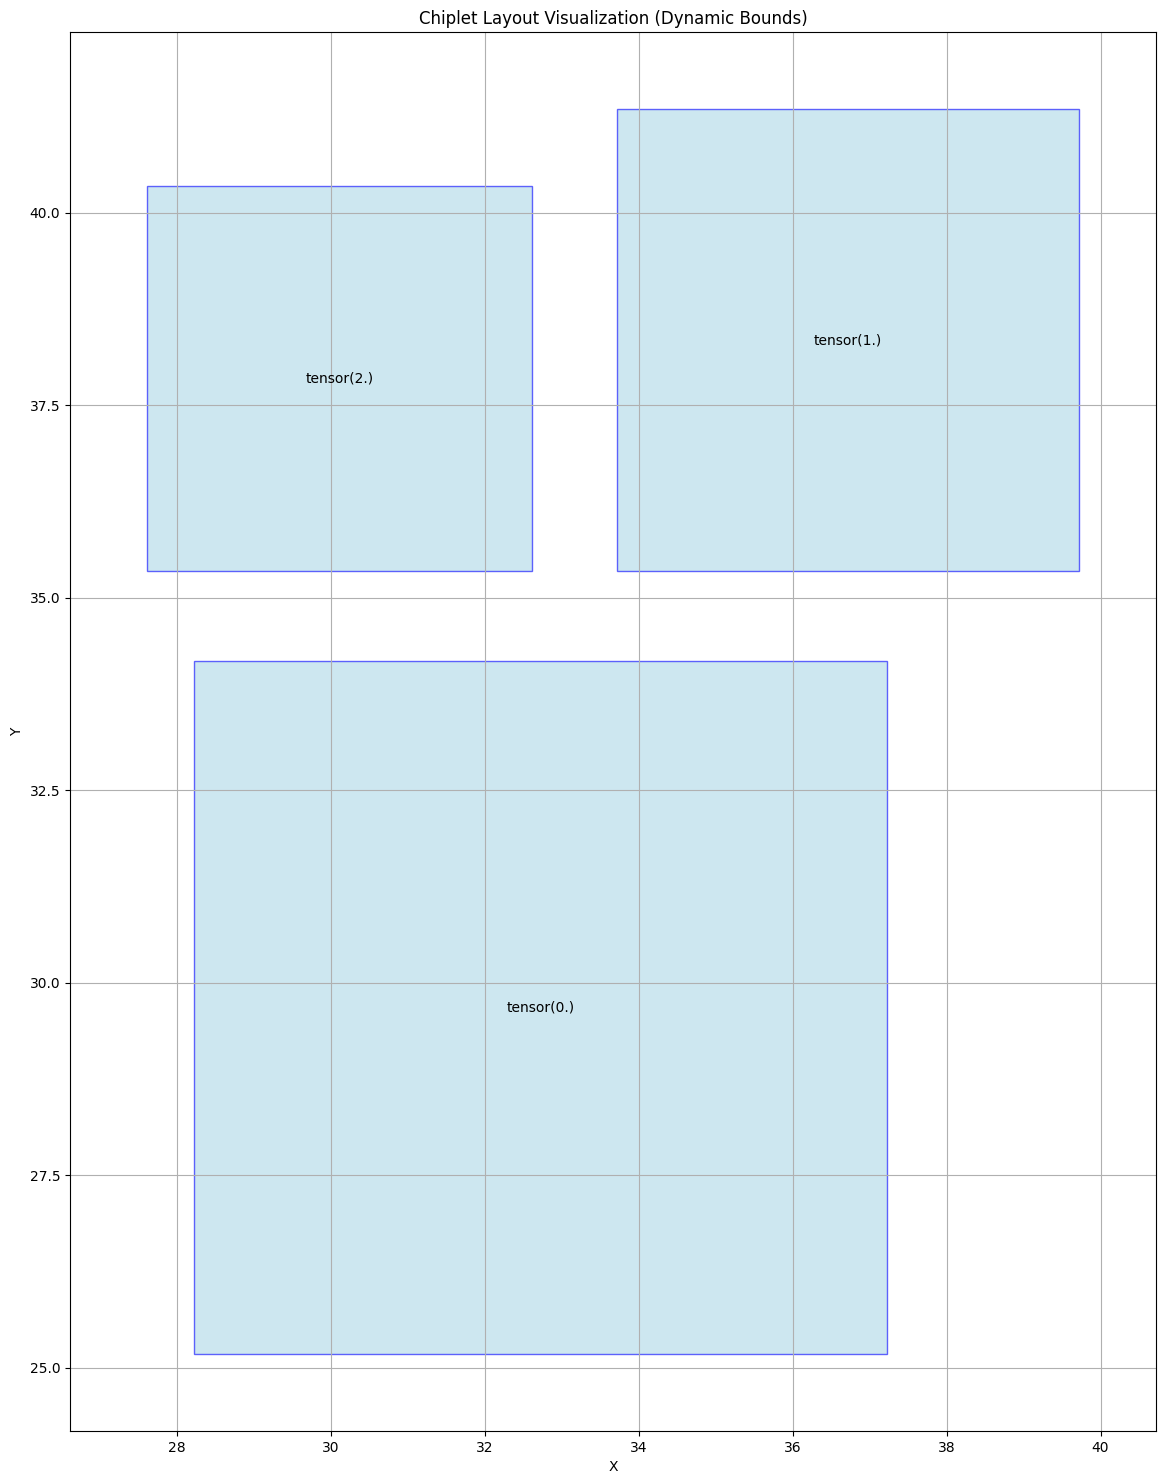

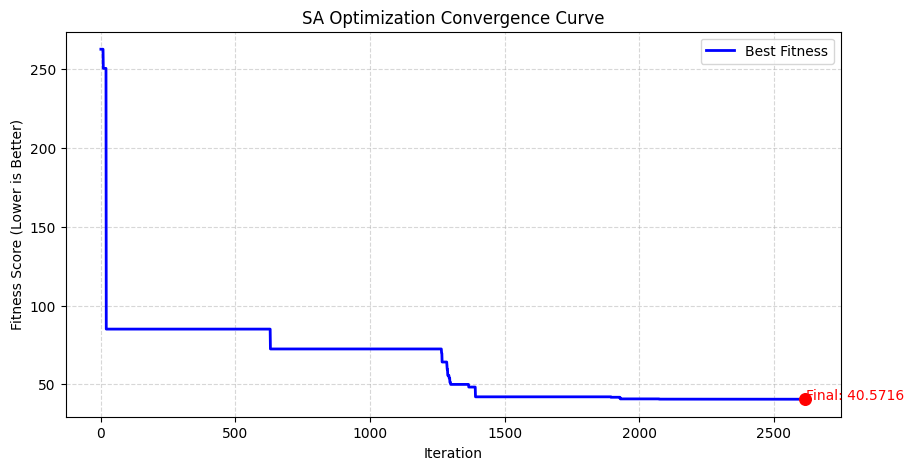

In [5]:
# 1. 定义测试数据（与 stage2_1_cuda03.ipynb 保持一致）
# 原始输入数据格式: [长, 宽, CFC, IHGM]
raw_input = [
    [9, 9, 15, 140000000],
    [6, 6, 15, 300000000],
    [5, 5, 15, 80000000],
    #[4, 4, 15, 120000000]
]

# 2. 构建 chiplets 字典
# 使用与 stage2_1_cuda03 相同的 A/k 计算方式，统一热模型参数口径
chiplets = {}
for i, d in enumerate(raw_input):
    chiplets[i] = get_chiplet_dict_cuda(
        chip_length=d[0],
        chip_width=d[1],
        Convection_Film_Coefficient=d[2],
        Internal_Heat_Generation_Magnitude=d[3]
    )

# 3. 定义连接关系（与 stage2_1_cuda03.ipynb 保持一致）
# 格式: [(芯片索引1, 芯片索引2), 连线权重]
connectivity = [
    [(0, 1), 1], 
    [(1, 2), 1], 
    [(0, 2), 1], 
    #[(0, 3), 1],
    #[(1, 3), 1], 
    #[(2, 3), 1]
]

# 4. 运行 SA 优化器
# 说明：这里保留 SA 的温控超参数，不改变“初始候选数量”相关设置
# 4. 在迭代运行前统一控制芯片间最小间距（后续只需修改这一处）
min_chip_spacing = 1.0

best_design, history = simulated_annealing_optimizer(
    chiplets=chiplets,
    connectivity=connectivity,
    initial_temp=5000,
    final_temp=0.01,
    alpha=0.995,
    max_iter_estimate=20000,
    min_edge_distance=min_chip_spacing
)

# 5. 打印结果
print("Best Design Layout:")
print(best_design)

def build_layout(best_positions, input_data):
    if torch.is_tensor(best_positions):
        rows = best_positions.detach().cpu().tolist()
    else:
        rows = best_positions

    layout = []
    for row_i, row in enumerate(rows):
        x = round(float(row[0]), 4)
        y = round(float(row[1]), 4)

        chip_idx = int(row_i)
        if len(row) >= 5:
            idx_raw = float(row[4])
            idx_int = int(idx_raw)
            if abs(idx_raw - idx_int) <= 1e-6 and 0 <= idx_int < len(input_data):
                chip_idx = idx_int

        if chip_idx < 0 or chip_idx >= len(input_data):
            raise ValueError(f"chip_idx out of range: {chip_idx}, valid [0, {len(input_data)-1}]")

        if len(row) >= 4:
            width = float(row[2])
            height = float(row[3])
        else:
            width = float(input_data[chip_idx][0])
            height = float(input_data[chip_idx][1])

        h = float(input_data[chip_idx][2])
        power_density = float(input_data[chip_idx][3])

        layout.append([
            x,
            y,
            width,
            height,
            h,
            power_density,
            int(chip_idx),
        ])

    for out_row in layout:
        idx = int(out_row[6])
        in_w = float(input_data[idx][0])
        in_h = float(input_data[idx][1])
        out_w = float(out_row[2])
        out_h = float(out_row[3])

        same_order = abs(out_w - in_w) <= 1e-6 and abs(out_h - in_h) <= 1e-6
        swapped_order = abs(out_w - in_h) <= 1e-6 and abs(out_h - in_w) <= 1e-6
        if not (same_order or swapped_order):
            raise ValueError(f"width/height mismatch at chip_idx={idx}: output=({out_w}, {out_h}), input=({in_w}, {in_h})")

    return layout

layout = build_layout(best_design, raw_input)
print("\nSA best fitness layout (unified format):")
print("layout = [")
for row in layout:
    print(f"    {row},")
print("]")


# 6. 可视化布局（避免 CUDA Tensor 直接转 numpy 报错）
import matplotlib.pyplot as plt

try:
    plot_design = best_design.detach().cpu() if torch.is_tensor(best_design) else best_design
    utilities.show_chip_design_cuda(plot_design)
except Exception as e:
    print(f"Visualization error: {e}")

# 7. 绘制收敛曲线
import numpy as np

# 使用累计最优值绘图：曲线单调不升，更直观看到收敛趋势
if len(history) == 0:
    print("history 为空，无法绘制收敛图")
else:
    best_history = np.minimum.accumulate(np.asarray(history, dtype=np.float32))

    import csv
    from pathlib import Path
    if Path("stage2_1").exists():
        sa_csv_path = Path("stage2_1") / "sa_fitness_history.csv"
    else:
        sa_csv_path = Path("sa_fitness_history.csv")
    with open(sa_csv_path, mode="w", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)
        writer.writerow(["iteration", "fitness"])
        for iter_idx, score in enumerate(best_history):
            writer.writerow([iter_idx, float(score)])
    print(f"SA CSV exported: {sa_csv_path.resolve()}")

    final_iter = len(best_history) - 1
    final_best = float(best_history[-1])

    plt.figure(figsize=(10, 5))
    plt.plot(best_history, color='blue', linewidth=2, label='Best Fitness')

    # 红点标记最终最优值，并显示具体数值
    plt.scatter([final_iter], [final_best], color='red', s=70, zorder=5)
    plt.text(final_iter + 0.5, final_best, f"Final: {final_best:.4f}", color='red')

    plt.title("SA Optimization Convergence Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Fitness Score (Lower is Better)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()
